# Debug CI Nodal 2023
Le fichier `ci_nodal_2023.nc` a 72% NaN et un max de 891k gCO2/kWh.
Diagnostiquons étape par étape.

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Charger les deux années
s22 = CarbonScorer.from_nodal_dir("/home/alexis/Greendc/carbon_model/data/outputs/ci_nodal", year=2022)
s23 = CarbonScorer.from_nodal_dir("/home/alexis/Greendc/carbon_model/data/outputs/ci_nodal", year=2023)

print('=== 2022 (janvier) ===')
ci22 = ds22['carbon_intensity'].values
print(f'Shape: {ci22.shape}')
print(f'Mean: {np.nanmean(ci22):.2f}')
print(f'% NaN: {100*np.mean(np.isnan(ci22)):.1f}%')
print(f'Max: {np.nanmax(ci22):.2f}')

print('\n=== 2023 ===')
ci23 = ds23['carbon_intensity'].values
print(f'Shape: {ci23.shape}')
print(f'Mean: {np.nanmean(ci23):.2f}')
print(f'% NaN: {100*np.mean(np.isnan(ci23)):.1f}%')
print(f'Max: {np.nanmax(ci23):.2f}')
print(f'Non-zero non-NaN mean: {np.nanmean(ci23[ci23 > 0]):.2f}')

NameError: name 'CarbonScorer' is not defined

/tmp/ipykernel_38726/972323221.py:2: RuntimeWarning: Mean of empty slice
  ci_mean_23 = np.nanmean(ci23, axis=0)


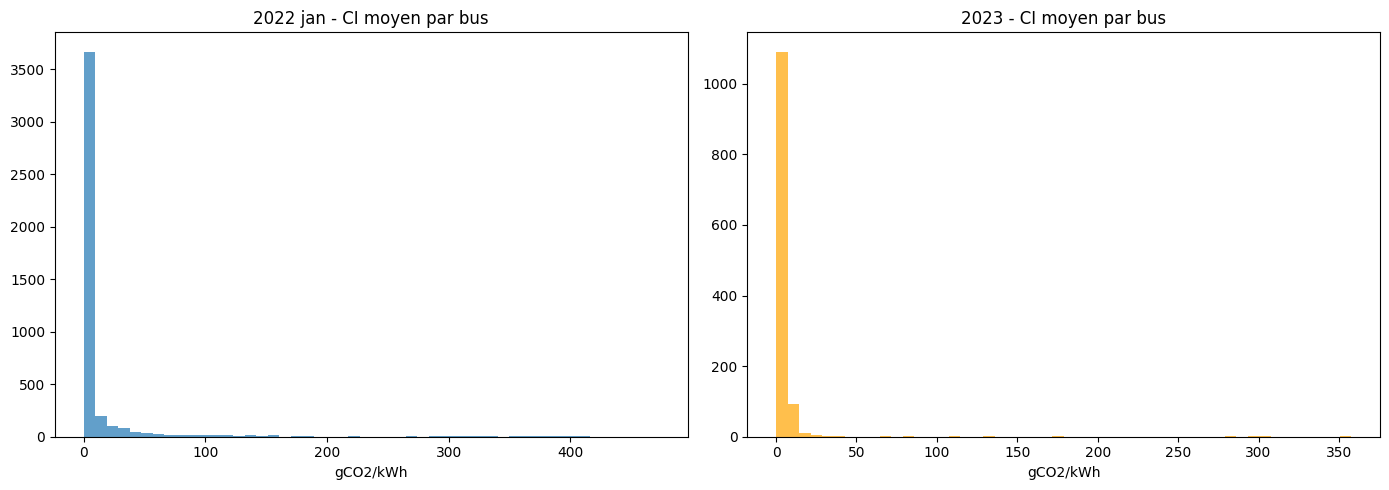

2022: 4393/4393 bus avec CI valide
2023: 1210/4393 bus avec CI valide


In [ ]:
# Distribution des CI moyennes par bus (2023)
ci_mean_23 = np.nanmean(ci23, axis=0)
ci_mean_22 = np.nanmean(ci22, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(ci_mean_22[~np.isnan(ci_mean_22)], bins=50, alpha=0.7)
axes[0].set_title('2022 jan - CI moyen par bus')
axes[0].set_xlabel('gCO2/kWh')

axes[1].hist(ci_mean_23[~np.isnan(ci_mean_23)], bins=50, alpha=0.7, color='orange')
axes[1].set_title('2023 - CI moyen par bus')
axes[1].set_xlabel('gCO2/kWh')

plt.tight_layout()
plt.show()

print(f'2022: {np.sum(~np.isnan(ci_mean_22))}/{len(ci_mean_22)} bus avec CI valide')
print(f'2023: {np.sum(~np.isnan(ci_mean_23))}/{len(ci_mean_23)} bus avec CI valide')

=== Top 10 bus CI max (2023) ===

=== % NaN par timestep (premiers/derniers) ===
  t=0: 72.5%
  t=100: 72.5%
  t=4000: 72.5%
  t=8000: 72.5%
  t=-1: 72.5%


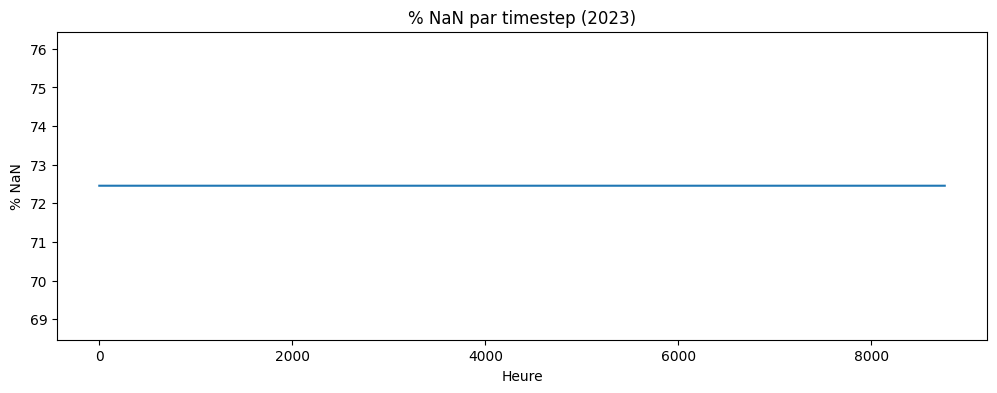

In [ ]:
# Regarder les valeurs extrêmes en 2023
print('=== Top 10 bus CI max (2023) ===')
bus_ids = ds23.coords['bus'].values.astype(str)
top_idx = np.argsort(ci_mean_23)[-10:][::-1]
for i in top_idx:
    if not np.isnan(ci_mean_23[i]):
        print(f'  Bus {bus_ids[i]}: CI = {ci_mean_23[i]:.1f} gCO2/kWh')

print(f'\n=== % NaN par timestep (premiers/derniers) ===')
nan_pct = 100 * np.mean(np.isnan(ci23), axis=1)
print(f'  t=0: {nan_pct[0]:.1f}%')
print(f'  t=100: {nan_pct[100]:.1f}%')
print(f'  t=4000: {nan_pct[4000]:.1f}%')
print(f'  t=8000: {nan_pct[8000]:.1f}%')
print(f'  t=-1: {nan_pct[-1]:.1f}%')

plt.figure(figsize=(12, 4))
plt.plot(nan_pct)
plt.title('% NaN par timestep (2023)')
plt.xlabel('Heure')
plt.ylabel('% NaN')
plt.show()

In [ ]:
import sys
sys.path.insert(0, '..')

from carbon_model.downloaders.download_rte import RTEDownloader

rte = RTEDownloader()
prod22 = rte.load_eco2mix_csv('../carbon_model/data/raw/rte/eco2mix_2022..xls')
prod23 = rte.load_eco2mix_csv('../carbon_model/data/raw/rte/eco2mix_2023.csv')

print('=== Production nationale (TWh) ===')
cols = ['nuclear', 'gas', 'wind', 'solar', 'hydro', 'oil', 'coal', 'biomass']
for col in cols:
    if col in prod22.columns and col in prod23.columns:
        twh22 = prod22[col].sum() / 1e6
        twh23 = prod23[col].sum() / 1e6
        print(f'  {col:12s}: 2022={twh22:6.1f}  2023={twh23:6.1f}  diff={twh23-twh22:+.1f}')

print(f'\n=== Colonnes 2022 ===')
print(list(prod22.columns))
print(f'\n=== Colonnes 2023 ===')
print(list(prod23.columns))

print(f'\n=== Mêmes colonnes ? ===')
print(set(prod22.columns) == set(prod23.columns))
print(f'Diff 2023-2022: {set(prod23.columns) - set(prod22.columns)}')
print(f'Diff 2022-2023: {set(prod22.columns) - set(prod23.columns)}')

2026-03-19 18:10:34.861 | WARNING  | carbon_model.downloaders.download_rte:load_eco2mix_csv:309 - Eco2mix tab terminal détecté : header=40 cols, data=41 cols → correction
2026-03-19 18:10:35.457 | SUCCESS  | carbon_model.downloaders.download_rte:load_eco2mix_csv:427 - Eco2mix chargé : 35040 timesteps
2026-03-19 18:10:35.460 | WARNING  | carbon_model.downloaders.download_rte:load_eco2mix_csv:309 - Eco2mix tab terminal détecté : header=40 cols, data=41 cols → correction
2026-03-19 18:10:36.042 | SUCCESS  | carbon_model.downloaders.download_rte:load_eco2mix_csv:427 - Eco2mix chargé : 35040 timesteps


=== Production nationale (TWh) ===

=== Colonnes 2022 ===
['Nuclear', 'Wind Onshore', 'Solar', 'Hydro Run-of-river', 'Biomass', 'Fossil Gas', 'Fossil Oil', 'Fossil Hard Coal', 'Hydro Pumped Storage', 'consumption_mw', 'net_exchanges_mw', 'co2_rate_gco2_kwh', 'exchange_GB_mw', 'exchange_ES_mw', 'exchange_IT_mw', 'exchange_CH_mw', 'exchange_DEBE_mw']

=== Colonnes 2023 ===
['Nuclear', 'Wind Onshore', 'Solar', 'Hydro Run-of-river', 'Biomass', 'Fossil Gas', 'Fossil Oil', 'Fossil Hard Coal', 'Hydro Pumped Storage', 'consumption_mw', 'net_exchanges_mw', 'co2_rate_gco2_kwh', 'exchange_GB_mw', 'exchange_ES_mw', 'exchange_IT_mw', 'exchange_CH_mw', 'exchange_DEBE_mw']

=== Mêmes colonnes ? ===
True
Diff 2023-2022: set()
Diff 2022-2023: set()


In [ ]:
# Vérifier le dispatch 2023 — est-ce que la production nodale est cohérente ?
import pypsa
from carbon_model.simulation.dispatch import disaggregate_national_to_nodes

n = pypsa.Network()
n.import_from_netcdf('../carbon_model/data/processed/network_france.nc')
print(f'Réseau: {len(n.buses)} bus, {len(n.generators)} generators')
print(f'\nGenerators par carrier:')
print(n.generators.groupby('carrier')['p_nom'].sum().sort_values(ascending=False))

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, lines


Réseau: 4393 bus, 0 generators

Generators par carrier:
Series([], Name: p_nom, dtype: float64)


In [ ]:
# Étape 5 : Vérifier les colonnes eco2mix 2022 vs 2023
# Le bug vient peut-être du décalage de colonnes (comme le bug 2022 initial)

prod22 = load_eco2mix_csv(2022)
prod23 = load_eco2mix_csv(2023)

print("=== Colonnes 2022 ===")
print(list(prod22.columns))
print(f"\n=== Colonnes 2023 ===") 
print(list(prod23.columns))

print(f"\n=== Mêmes colonnes ? ===")
print(set(prod22.columns) == set(prod23.columns))
print(f"Diff 2023-2022: {set(prod23.columns) - set(prod22.columns)}")
print(f"Diff 2022-2023: {set(prod22.columns) - set(prod23.columns)}")

print(f"\n=== Production moyenne (MW) ===")
for col in sorted(set(prod22.columns) & set(prod23.columns)):
    m22 = prod22[col].mean()
    m23 = prod23[col].mean()
    if abs(m22) > 1 or abs(m23) > 1:
        ratio = m23/m22 if m22 != 0 else float('inf')
        flag = " ⚠️" if abs(ratio - 1) > 0.5 else ""
        print(f"  {col:20s}: 2022={m22:8.0f}  2023={m23:8.0f}  ratio={ratio:.2f}{flag}")

NameError: name 'load_eco2mix_csv' is not defined

In [ ]:
# Test complet du fix (1 semaine 2023)
import sys
sys.path.insert(0, '..')
import importlib, carbon_model.downloaders.download_rte
importlib.reload(carbon_model.downloaders.download_rte)

from pathlib import Path
from carbon_model.downloaders.download_rte import RTEDownloader
import pypsa
import numpy as np
import geopandas as gpd
from carbon_model.plants.plant_integrator import add_generators_to_network
from carbon_model.simulation.dispatch import disaggregate_national_to_nodes
from carbon_model.simulation.power_flow import run_dc_power_flow
from carbon_model.tracing.carbon_tracing import compute_nodal_carbon_intensity

# 1. Charger eco2mix 2023
rte = RTEDownloader()
prod = rte.load_eco2mix_csv(Path("../carbon_model/data/raw/rte/eco2mix_2023.csv"))
print(f"Nuclear mean: {prod['Nuclear'].mean():.0f} MW (attendu ~18000)")

prod_h = prod.resample("h").mean()
prod_h = prod_h[prod_h["Nuclear"] > 0]
print(f"Timesteps horaires: {len(prod_h)}")

# 2. Reseau + centrales (depuis le geojson pre-snapped)
n = pypsa.Network()
n.import_from_netcdf("../carbon_model/data/processed/network_france.nc")
plants_gdf = gpd.read_file("../carbon_model/data/processed/plants_snapped.geojson")
n = add_generators_to_network(n, plants_gdf)
print(f"Reseau: {len(n.buses)} bus, {len(n.generators)} gen")

# 3. Dispatch 1 semaine
week = prod_h.iloc[:168]
print(f"\nSemaine: {week.index[0]} -> {week.index[-1]}")
gen_ts = disaggregate_national_to_nodes(n, week)
print(f"Dispatch OK: {gen_ts.shape}")
# Injecter le dispatch dans le réseau PyPSA
n.set_snapshots(week.index)

# Mapper les colonnes du dispatch vers les generators du réseau
tech_cols = ["Nuclear", "Wind Onshore", "Solar", "Hydro Run-of-river", 
             "Biomass", "Fossil Gas", "Fossil Oil", "Fossil Hard Coal"]
carrier_map = {
    "Nuclear": "nuclear", "Wind Onshore": "wind", "Solar": "solar",
    "Hydro Run-of-river": "hydro", "Biomass": "biomass",
    "Fossil Gas": "gas", "Fossil Oil": "oil", "Fossil Hard Coal": "coal"
}

# Production par generator = national * (p_nom_gen / sum_p_nom_carrier)
for col in tech_cols:
    carrier = carrier_map.get(col)
    if carrier is None or col not in week.columns:
        continue
    gens = n.generators[n.generators.carrier == carrier]
    if gens.empty:
        continue
    total_cap = gens.p_nom.sum()
    for gen_id, gen in gens.iterrows():
        ratio = gen.p_nom / total_cap if total_cap > 0 else 0
        n.generators_t.p_set[gen_id] = week[col].values * ratio

# Loads = consommation repartie uniformement
if "consumption_mw" in week.columns:
    n_buses = len(n.buses)
    for bus in n.buses.index:
        load_name = f"load_{bus}"
        if load_name not in n.loads.index:
            n.add("Load", load_name, bus=bus)
        n.loads_t.p_set[load_name] = week["consumption_mw"].values / n_buses

print(f"p_set shape: {n.generators_t.p_set.shape}")
print(f"p_set sum t=0: {n.generators_t.p_set.iloc[0].sum():.0f} MW")
print(f"loads shape: {n.loads_t.p_set.shape}")
print(f"loads sum t=0: {n.loads_t.p_set.iloc[0].sum():.0f} MW")

# 4. Power flow
n_pf = run_dc_power_flow(n, week.index)
print("Power flow OK")

# 5. Tracing
ds = compute_nodal_carbon_intensity(n_pf, week.index)
print(type(ds))
ci_vals = ds["carbon_intensity"].values
print(f"\n=== CI nodal 2023 (1 semaine) ===")
print(f"Shape: {ci_vals.shape}")
print(f"Mean: {np.nanmean(ci_vals):.2f} gCO2/kWh")
print(f"% NaN: {100*np.mean(np.isnan(ci_vals)):.1f}%")
print(f"Max: {np.nanmax(ci_vals):.2f}")
print(f"Bus avec CI valide: {np.sum(~np.isnan(np.nanmean(ci_vals, axis=0)))}/{ci_vals.shape[1]}")



2026-03-20 14:25:46.839 | WARNING  | carbon_model.downloaders.download_rte:load_eco2mix_csv:309 - Eco2mix tab terminal détecté : header=40 cols, data=41 cols → correction
2026-03-20 14:25:47.615 | SUCCESS  | carbon_model.downloaders.download_rte:load_eco2mix_csv:427 - Eco2mix chargé : 35040 timesteps


Nuclear mean: 18276 MW (attendu ~18000)
Timesteps horaires: 8760


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, lines
2026-03-20 14:25:48.820 | INFO     | carbon_model.plants.plant_integrator:add_generators_to_network:229 - Agrégation centrales : 45937 → 3115 (bus × tech)
2026-03-20 14:27:45.075 | SUCCESS  | carbon_model.plants.plant_integrator:add_generators_to_network:249 - Générateurs ajoutés au réseau : 3115
Capacité totale : 156.3 GW
2026-03-20 14:27:45.077 | INFO     | carbon_model.simulation.dispatch:disaggregate_national_to_nodes:44 - Désagrégation production nationale → nœuds (méthode: capacity_weighted)
2026-03-20 14:27:45.167 | SUCCESS  | carbon_model.simulation.dispatch:disaggregate_national_to_nodes:86 - Dispatch vectorisé : 168 timesteps × 3115 générateurs
/tmp/ipykernel_38726/322387465.py:61: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get 

Reseau: 4393 bus, 3115 gen

Semaine: 2023-01-01 00:00:00 -> 2023-01-07 23:00:00
Dispatch OK: (168, 3115)


/tmp/ipykernel_38726/322387465.py:61: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_38726/322387465.py:61: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_38726/322387465.py:61: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/tmp/ipykernel_38726/322387465.py:61: Performance

...

INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x7495bd979400> for snapshot(s) DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 01:00:00',
               '2023-01-01 02:00:00', '2023-01-01 03:00:00',
               '2023-01-01 04:00:00', '2023-01-01 05:00:00',
               '2023-01-01 06:00:00', '2023-01-01 07:00:00',
               '2023-01-01 08:00:00', '2023-01-01 09:00:00',
               ...
               '2023-01-07 14:00:00', '2023-01-07 15:00:00',
               '2023-01-07 16:00:00', '2023-01-07 17:00:00',
               '2023-01-07 18:00:00', '2023-01-07 19:00:00',
               '2023-01-07 20:00:00', '2023-01-07 21:00:00',
               '2023-01-07 22:00:00', '2023-01-07 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=168, freq='h')
INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x7495bd97a120> for snapshot(s) Dat

INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x7495bd979820> for snapshot(s) DatetimeIndex(['2023-01-01 00:00:00', '2023-01-01 01:00:00',
               '2023-01-01 02:00:00', '2023-01-01 03:00:00',
               '2023-01-01 04:00:00', '2023-01-01 05:00:00',
               '2023-01-01 06:00:00', '2023-01-01 07:00:00',
               '2023-01-01 08:00:00', '2023-01-01 09:00:00',
               ...
               '2023-01-07 14:00:00', '2023-01-07 15:00:00',
               '2023-01-07 16:00:00', '2023-01-07 17:00:00',
               '2023-01-07 18:00:00', '2023-01-07 19:00:00',
               '2023-01-07 20:00:00', '2023-01-07 21:00:00',
               '2023-01-07 22:00:00', '2023-01-07 23:00:00'],
              dtype='datetime64[us]', name='snapshot', length=168, freq='h')
INFO:pypsa.network.power_flow:Performing linear load-flow on AC sub-network <pypsa.networks.SubNetwork object at 0x7495bd97aed0> for snapshot(s) Dat

Power flow OK


Carbon tracing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 168/168 [02:04<00:00,  1.35it/s]
2026-03-20 14:32:43.666 | SUCCESS  | carbon_model.tracing.carbon_tracing:compute_nodal_carbon_intensity:356 - Carbon intensity calculée :
  Valeur moyenne : 10.7 gCO2/kWh
  Min            : 0.0 gCO2/kWh
  Max            : 1778753.3 gCO2/kWh
  NaN            : 0 / 738024 (0.0%)


<class 'xarray.core.dataset.Dataset'>

=== CI nodal 2023 (1 semaine) ===
Shape: (168, 4393)
Mean: 10.67 gCO2/kWh
% NaN: 0.0%
Max: 1778753.29
Bus avec CI valide: 4393/4393


In [ ]:
# Diagnostic des outliers tracing 2023
import numpy as np

ci = ds["carbon_intensity"].values  # (168, 4393)

# Combien de valeurs > 1000 ?
print(f"Valeurs > 1000: {np.sum(ci > 1000)} / {ci.size} ({100*np.mean(ci > 1000):.4f}%)")
print(f"Valeurs > 10000: {np.sum(ci > 10000)}")
print(f"Valeurs > 100000: {np.sum(ci > 100000)}")
print(f"Valeurs > 1000000: {np.sum(ci > 1000000)}")

# Top 10 valeurs max
flat = ci.flatten()
top_idx = np.argsort(flat)[-10:][::-1]
times = ds.coords["time"].values
buses = ds.coords["bus"].values
print("\n=== Top 10 valeurs aberrantes ===")
for idx in top_idx:
    t_i = idx // ci.shape[1]
    b_i = idx % ci.shape[1]
    print(f"  CI={flat[idx]:12.1f}  bus={buses[b_i]}  time={times[t_i]}")

# Distribution sans outliers
clean = ci[ci < 500]
print(f"\n=== Sans outliers (CI < 500) ===")
print(f"Mean: {np.mean(clean):.2f}")
print(f"P50: {np.median(clean):.2f}")
print(f"P95: {np.percentile(clean, 95):.2f}")
print(f"Max: {np.max(clean):.2f}")
print(f"% du dataset: {100*len(clean)/ci.size:.1f}%")


Valeurs > 1000: 312 / 738024 (0.0423%)
Valeurs > 10000: 28
Valeurs > 100000: 4
Valeurs > 1000000: 1

=== Top 10 valeurs aberrantes ===
  CI=   1778753.3  bus=way/148059536-225  time=2023-01-01T20:00:00.000000
  CI=    245522.9  bus=relation/13260100-400  time=2023-01-06T17:00:00.000000
  CI=    221075.0  bus=way/601808882-225  time=2023-01-01T20:00:00.000000
  CI=    137155.3  bus=way/601808882-225  time=2023-01-05T04:00:00.000000
  CI=     69529.1  bus=way/148059536-225  time=2023-01-05T04:00:00.000000
  CI=     62030.6  bus=way/183822179-225  time=2023-01-01T05:00:00.000000
  CI=     50445.5  bus=relation/13260100-400  time=2023-01-06T16:00:00.000000
  CI=     46599.9  bus=way/156953619-225  time=2023-01-03T10:00:00.000000
  CI=     40888.1  bus=FR21-225  time=2023-01-02T14:00:00.000000
  CI=     39535.2  bus=way/601808882-225  time=2023-01-06T14:00:00.000000

=== Sans outliers (CI < 500) ===
Mean: 5.21
P50: 0.00
P95: 24.36
Max: 499.55
% du dataset: 99.9%


In [ ]:
# Diagnostic power flow
print("=== Power flow results ===")
print(f"Lines p0 shape: {n_pf.lines_t.p0.shape}")
print(f"Lines p0 non-zero: {(n_pf.lines_t.p0 != 0).sum().sum()}")
print(f"Lines p0 max: {n_pf.lines_t.p0.abs().max().max():.0f} MW")

print(f"\nGenerators p shape: {n_pf.generators_t.p.shape}")
print(f"Generators p non-zero: {(n_pf.generators_t.p != 0).sum().sum()}")
print(f"Generators p_set shape: {n_pf.generators_t.p_set.shape}")

print(f"\nLoads p shape: {n_pf.loads_t.p.shape}")
print(f"Loads p non-zero: {(n_pf.loads_t.p != 0).sum().sum()}")

print(f"\nBuses p shape: {n_pf.buses_t.p.shape}")
print(f"Buses p non-zero: {(n_pf.buses_t.p != 0).sum().sum()}")

# Check si les generators ont des carriers
print(f"\nGenerators carriers:")
print(n_pf.generators.groupby('carrier')['p_nom'].sum().sort_values(ascending=False))


=== Power flow results ===
Lines p0 shape: (168, 5888)
Lines p0 non-zero: 989184
Lines p0 max: 12025 MW

Generators p shape: (168, 3115)
Generators p non-zero: 366960
Generators p_set shape: (168, 2760)

Loads p shape: (168, 4393)
Loads p non-zero: 738024

Buses p shape: (168, 4393)
Buses p non-zero: 737184

Generators carriers:
carrier
nuclear          62990.000000
hydro            25452.771350
wind             24011.882710
solar            20466.045118
gas              12748.640570
oil               2555.182400
biomass           2554.278699
wind_offshore     2008.200000
coal              1810.719000
storage           1453.356000
other              288.734000
geothermal           1.850000
Name: p_nom, dtype: float64


In [ ]:
# Comparaison scoring 2022 vs 2023 (mêmes villes)
from carbon_model.scoring import CarbonScorer

# Scorer 2023 (depuis le ds qu'on vient de calculer - 1 semaine)
s23 = CarbonScorer(ds)

# Scorer 2022 (depuis les fichiers mensuels)
s22 = CarbonScorer.from_nodal_dir("../carbon_model/data/outputs/ci_nodal", year=2022)

villes = {
    "Paris": (48.86, 2.35),
    "Lyon": (45.76, 4.83),
    "Marseille": (43.30, 5.37),
    "Lille": (50.63, 3.06),
    "Strasbourg": (48.57, 7.75),
    "Bordeaux": (44.84, -0.58),
    "Nantes": (47.22, -1.55),
    "Toulouse": (43.60, 1.44),
    "Gravelines": (50.99, 2.13),
    "Martigues": (43.40, 5.05),
}

print(f"{'Ville':15s} {'2022':>8s} {'2023':>8s} {'Delta':>8s} {'Plausible':>10s}")
print("-" * 55)
for ville, (lat, lon) in villes.items():
    r22 = s22.score(lat, lon)
    r23 = s23.score(lat, lon)
    delta = r23["ci_gco2kwh"] - r22["ci_gco2kwh"]
    # Plausible si entre 20 et 80 gCO2/kWh pour la France
    ok = "OK" if 20 < r23["ci_gco2kwh"] < 80 else "??"
    print(f"{ville:15s} {r22['ci_gco2kwh']:7.1f}  {r23['ci_gco2kwh']:7.1f}  {delta:+7.1f}  {ok:>8s}")


Ville               2022     2023    Delta  Plausible
-------------------------------------------------------
Paris              48.4     15.6    -32.8        ??
Lyon               35.6     43.5     +7.9        OK
Marseille          45.6     48.4     +2.8        OK
Lille              58.2     26.6    -31.6        OK
Strasbourg         45.9      7.4    -38.4        ??
Bordeaux           55.8     37.8    -18.1        OK
Nantes             61.9     35.2    -26.7        OK
Toulouse           55.5     65.5    +10.0        OK
Gravelines         33.5     16.7    -16.8        ??
Martigues          50.2     53.6     +3.4        OK


In [4]:
import sys
sys.path.insert(0, '..')
import importlib, carbon_model.scoring
importlib.reload(carbon_model.scoring)
from carbon_model.scoring import CarbonScorer

s22 = CarbonScorer.from_nodal_dir("/home/alexis/Greendc/carbon_model/data/outputs/ci_nodal", year=2022)
s23 = CarbonScorer.from_nodal_dir("/home/alexis/Greendc/carbon_model/data/outputs/ci_nodal", year=2023)

villes = {
    "Paris": (48.86, 2.35), "Lyon": (45.76, 4.83),
    "Marseille": (43.30, 5.37), "Lille": (50.63, 3.06),
    "Strasbourg": (48.57, 7.75), "Bordeaux": (44.84, -0.58),
    "Nantes": (47.22, -1.55), "Toulouse": (43.60, 1.44),
    "Gravelines": (50.99, 2.13), "Martigues": (43.40, 5.05),
    "Rennes": (48.11, -1.68), "Montpellier": (43.61, 3.88),
    "Nice": (43.70, 7.27), "Rouen": (49.44, 1.10),
    "Dijon": (47.32, 5.04), "Grenoble": (45.19, 5.72),
    "Tours": (47.39, 0.69), "Clermont-Fd": (45.78, 3.08),
    "Le Havre": (49.49, 0.11), "Dunkerque": (51.03, 2.38),
    "Fos-sur-Mer": (43.44, 4.94), "Cattenom": (49.41, 6.22),
    "Flamanville": (49.54, -1.88), "Chinon": (47.23, 0.17),
    "Civaux": (46.44, 0.66), "Saint-Brieuc": (48.51, -2.76),
    "Brest": (48.39, -4.49), "Perpignan": (42.70, 2.90),
    "Bayonne": (43.49, -1.47), "Metz": (49.12, 6.18),
}

print(f"{'Ville':15s} {'2022':>8s} {'2023':>8s} {'Delta':>8s} {'Check':>8s}")
print("-" * 55)
n_ok = 0
for v, (lat, lon) in villes.items():
    r22 = s22.score(lat, lon)
    r23 = s23.score(lat, lon)
    d = r23["ci_gco2kwh"] - r22["ci_gco2kwh"]
    ok = "OK" if 20 < r23["ci_gco2kwh"] < 80 else "??"
    if ok == "OK": n_ok += 1
    print(f"{v:15s} {r22['ci_gco2kwh']:7.1f}  {r23['ci_gco2kwh']:7.1f}  {d:+7.1f}  {ok:>6s}")

print(f"\nPlausibles: {n_ok}/30 ({100*n_ok/30:.0f}%)")


Ville               2022     2023    Delta    Check
-------------------------------------------------------
Paris              48.4      4.1    -44.3      ??
Lyon               35.6      2.5    -33.1      ??
Marseille          45.6      2.5    -43.1      ??
Lille              58.2      4.7    -53.5      ??
Strasbourg         45.9      7.9    -37.9      ??
Bordeaux           55.8      6.7    -49.1      ??
Nantes             61.9      7.0    -54.9      ??
Toulouse           55.5      2.7    -52.7      ??
Gravelines         33.5      4.1    -29.4      ??
Martigues          50.2      2.8    -47.4      ??
Rennes             59.7      7.2    -52.4      ??
Montpellier        40.8      2.7    -38.1      ??
Nice               30.5      2.5    -28.0      ??
Rouen              53.6      4.4    -49.1      ??
Dijon              40.5      5.2    -35.4      ??
Grenoble           39.0      2.5    -36.5      ??
Tours              47.7      6.0    -41.7      ??
Clermont-Fd        41.1      2.7    -38.4 

/home/alexis/Greendc/carbon_model/scoring.py:42: RuntimeWarning: Mean of empty slice
  self._ci_mean = np.nanmean(ds["carbon_intensity"].values, axis=0)


In [3]:
import sys
sys.path.insert(0, '..')
import importlib, carbon_model.scoring
importlib.reload(carbon_model.scoring)
from carbon_model.scoring import CarbonScorer

s22 = CarbonScorer.from_nodal_dir("/home/alexis/Greendc/carbon_model/data/outputs/ci_nodal", year=2022)

villes = {
    "Paris": (48.86, 2.35), "Lyon": (45.76, 4.83),
    "Marseille": (43.30, 5.37), "Lille": (50.63, 3.06),
    "Strasbourg": (48.57, 7.75), "Bordeaux": (44.84, -0.58),
    "Nantes": (47.22, -1.55), "Toulouse": (43.60, 1.44),
    "Gravelines": (50.99, 2.13), "Martigues": (43.40, 5.05),
    "Rennes": (48.11, -1.68), "Montpellier": (43.61, 3.88),
    "Nice": (43.70, 7.27), "Rouen": (49.44, 1.10),
    "Dijon": (47.32, 5.04), "Grenoble": (45.19, 5.72),
    "Tours": (47.39, 0.69), "Clermont-Fd": (45.78, 3.08),
    "Le Havre": (49.49, 0.11), "Dunkerque": (51.03, 2.38),
    "Fos-sur-Mer": (43.44, 4.94), "Cattenom": (49.41, 6.22),
    "Flamanville": (49.54, -1.88), "Chinon": (47.23, 0.17),
    "Civaux": (46.44, 0.66), "Saint-Brieuc": (48.51, -2.76),
    "Brest": (48.39, -4.49), "Perpignan": (42.70, 2.90),
    "Bayonne": (43.49, -1.47), "Metz": (49.12, 6.18),
}

print(f"{'Ville':15s} {'CI score':>10s} {'CI brut':>10s} {'CI zone':>10s}")
print("-" * 50)
n_ok = 0
for v, (lat, lon) in villes.items():
    r = s22.score(lat, lon)
    ok = "OK" if 20 < r["ci_gco2kwh"] < 80 else "??"
    if ok == "OK": n_ok += 1
    print(f"{v:15s} {r['ci_gco2kwh']:8.1f}   {r['ci_brut_gco2kwh']:8.1f}   {r['ci_zone_gco2kwh']:8.1f}  {ok}")

print(f"\nPlausibles: {n_ok}/30 ({100*n_ok/30:.0f}%)")


Ville             CI score    CI brut    CI zone
--------------------------------------------------
Paris               48.4       39.9       49.4  OK
Lyon                35.6       13.1       39.8  OK
Marseille           45.6      156.1       39.8  OK
Lille               58.2      254.5       49.4  OK
Strasbourg          45.9      164.9       39.8  OK
Bordeaux            55.8       77.1       53.9  OK
Nantes              61.9      217.1       53.9  OK
Toulouse            55.5       72.3       53.9  OK
Gravelines          33.5        0.0       49.4  OK
Martigues           50.2      408.1       39.8  OK
Rennes              59.7      149.4       53.9  OK
Montpellier         40.8       51.5       39.8  OK
Nice                30.5        2.8       39.8  OK
Rouen               53.6      110.6       49.4  OK
Dijon               40.5       48.0       39.8  OK
Grenoble            39.0       32.8       39.8  OK
Tours               47.7       16.1       53.9  OK
Clermont-Fd         41.1       54